# Face Gallery — Enroll, Search & Recognize

This notebook demonstrates the full gallery pipeline:

1. Load the trained embedding model
2. Enroll faces (build the gallery)
3. Search with a query face → ranked results
4. Multi-image enrollment → accuracy improvement
5. Unknown face → low-confidence detection
6. Gallery management (list, inspect, delete)

## 0. Setup

In [13]:
import sys
import csv
import random
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

# Project root (adjust if running from a different directory)
PROJECT_ROOT = Path('.')
sys.path.insert(0, str(PROJECT_ROOT))

from gallery import GalleryManager

## 1. Initialize Gallery Manager

Loads the trained model from checkpoint and initializes (or loads) the gallery.

In [14]:
CHECKPOINT = PROJECT_ROOT / 'checkpoints' / 'best.pt'
GALLERY_DIR = PROJECT_ROOT / 'gallery'

gm = GalleryManager(
    gallery_dir=str(GALLERY_DIR),
    checkpoint_path=str(CHECKPOINT),
    threshold=0.5,
)
print(f'Identities: {gm.identity_count}, Images: {gm.total_image_count}')

[Gallery] Model loaded from checkpoints/best.pt (epoch 29, dim=256)
[Gallery] Loaded 5 identities, 8 images
Identities: 5, Images: 8


## 2. Discover Sample Images from Dataset

We'll pick a few identities from the manifest to demonstrate enrollment.

In [38]:
MANIFEST = PROJECT_ROOT / 'dataset' / 'splits' / 'manifest.csv'

# Parse manifest and group by subject_id
subject_images = defaultdict(list)
with open(MANIFEST) as f:
    for row in csv.DictReader(f):
        img_path = PROJECT_ROOT / row['path']
        if img_path.exists():
            subject_images[row['subject_id']].append(img_path)

# Pick subjects with at least 5 images for a good demo
candidates = [
    (sid, paths) for sid, paths in subject_images.items()
    if len(paths) >= 5
]
random.seed(11)
demo_subjects = random.sample(candidates, min(5, len(candidates)))

print(f'Selected {len(demo_subjects)} demo subjects:')
for sid, paths in demo_subjects:
    print(f'  {sid}: {len(paths)} images')

Selected 5 demo subjects:
  synthetic_1534: 72 images
  synthetic_1615: 72 images
  synthetic_1398: 72 images
  synthetic_1622: 72 images
  synthetic_1276: 72 images


## 3. Enroll Faces (Single Image per Identity)

Enroll one image per identity to build the initial gallery.

In [39]:
# Clear gallery for a clean demo
for identity in gm.list_identities():
    gm.delete_identity(identity['identity_id'])

# Enroll first image of each subject
for sid, paths in demo_subjects:
    gm.enroll(
        identity_id=sid,
        label=sid.replace('_', ' ').title(),
        image_path=str(paths[0]),
    )

print(f'\nGallery now has {gm.identity_count} identities')

[Delete] Removed 'Synthetic 178' (id=synthetic_178)
[Delete] Removed 'Synthetic 1193' (id=synthetic_1193)
[Delete] Removed 'Synthetic 765' (id=synthetic_765)
[Delete] Removed 'Synthetic 663' (id=synthetic_663)
[Delete] Removed 'Synthetic 392' (id=synthetic_392)
[Enroll] 'Synthetic 1534' (id=synthetic_1534) — 1 image(s) total
[Enroll] 'Synthetic 1615' (id=synthetic_1615) — 1 image(s) total
[Enroll] 'Synthetic 1398' (id=synthetic_1398) — 1 image(s) total
[Enroll] 'Synthetic 1622' (id=synthetic_1622) — 1 image(s) total
[Enroll] 'Synthetic 1276' (id=synthetic_1276) — 1 image(s) total

Gallery now has 5 identities


## 4. Search — Find Similar Faces

Query with a **different image** of the first enrolled subject. The correct identity should rank #1.

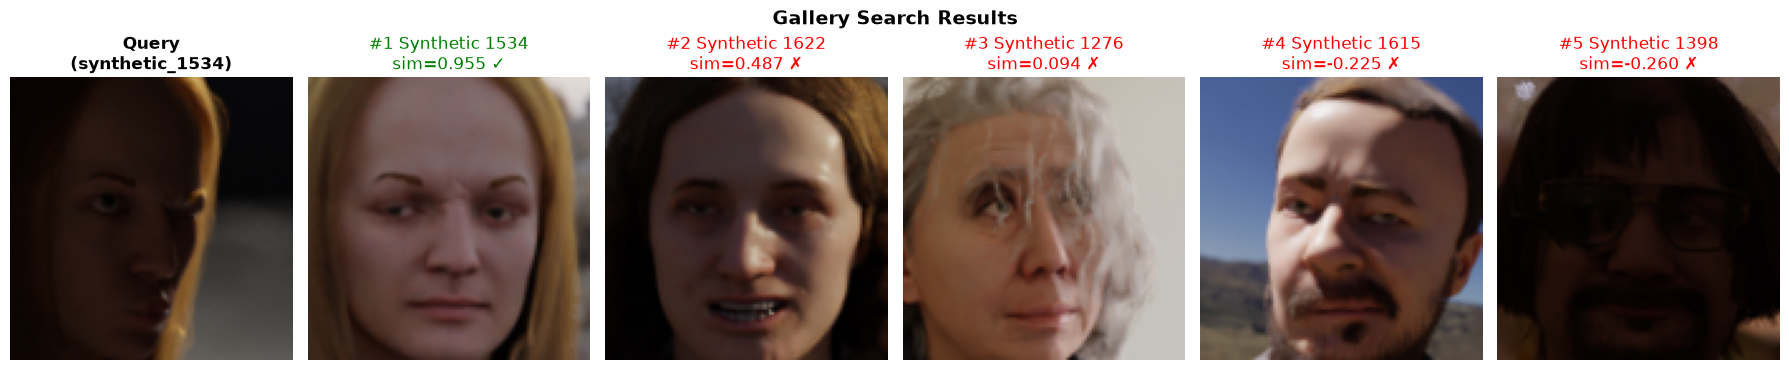

✓ Correct! Top match is synthetic_1534


In [40]:
# Use second image of first subject as query
query_sid, query_paths = demo_subjects[0]
query_image = str(query_paths[1])  # different image, same person

results = gm.search(query_image, top_k=5)

# Display results
fig, axes = plt.subplots(1, len(results) + 1, figsize=(3 * (len(results) + 1), 4))

# Show query
axes[0].imshow(Image.open(query_image))
axes[0].set_title(f'Query\n({query_sid})', fontweight='bold')
axes[0].axis('off')

# Show ranked results
for i, r in enumerate(results):
    ax = axes[i + 1]
    # Show first stored image for this identity
    stored_images = gm.get_identity_image_paths(r['identity_id'])
    if stored_images:
        ax.imshow(Image.open(stored_images[0]))
    conf_marker = '✓' if r['confident'] else '✗'
    color = 'green' if r['confident'] else 'red'
    ax.set_title(
        f"#{i+1} {r['label']}\n"
        f"sim={r['similarity']:.3f} {conf_marker}",
        color=color,
    )
    ax.axis('off')

plt.suptitle('Gallery Search Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify correct match
if results and results[0]['identity_id'] == query_sid:
    print(f'✓ Correct! Top match is {query_sid}')
else:
    print(f'✗ Mismatch — top result: {results[0]["identity_id"] if results else "none"}')

## 5. Multi-Image Enrollment → Accuracy Boost

Enroll additional images for the first subject and observe how the similarity score improves. More images → better mean embedding.

In [41]:
target_sid, target_paths = demo_subjects[0]
query_image = str(target_paths[1])

# Baseline: search with 1 enrolled image
baseline_results = gm.search(query_image, top_k=1)
baseline_sim = baseline_results[0]['similarity'] if baseline_results else 0
print(f'Baseline (1 image):  similarity = {baseline_sim:.4f}')

# Enroll 3 more images
for extra_path in target_paths[2:5]:
    gm.enroll(
        identity_id=target_sid,
        label=target_sid.replace('_', ' ').title(),
        image_path=str(extra_path),
    )

# Search again with more enrolled images
improved_results = gm.search(query_image, top_k=1)
improved_sim = improved_results[0]['similarity'] if improved_results else 0
print(f'After (4 images):    similarity = {improved_sim:.4f}')
print(f'Improvement:         +{improved_sim - baseline_sim:.4f}')

Baseline (1 image):  similarity = 0.9551
[Enroll] 'Synthetic 1534' (id=synthetic_1534) — 2 image(s) total
[Enroll] 'Synthetic 1534' (id=synthetic_1534) — 3 image(s) total
[Enroll] 'Synthetic 1534' (id=synthetic_1534) — 4 image(s) total
After (4 images):    similarity = 0.9383
Improvement:         +-0.0168


## 6. Unknown Face → Low Confidence Detection

Query with a face from a subject **not** in the gallery. All results should be flagged as low confidence (below threshold).

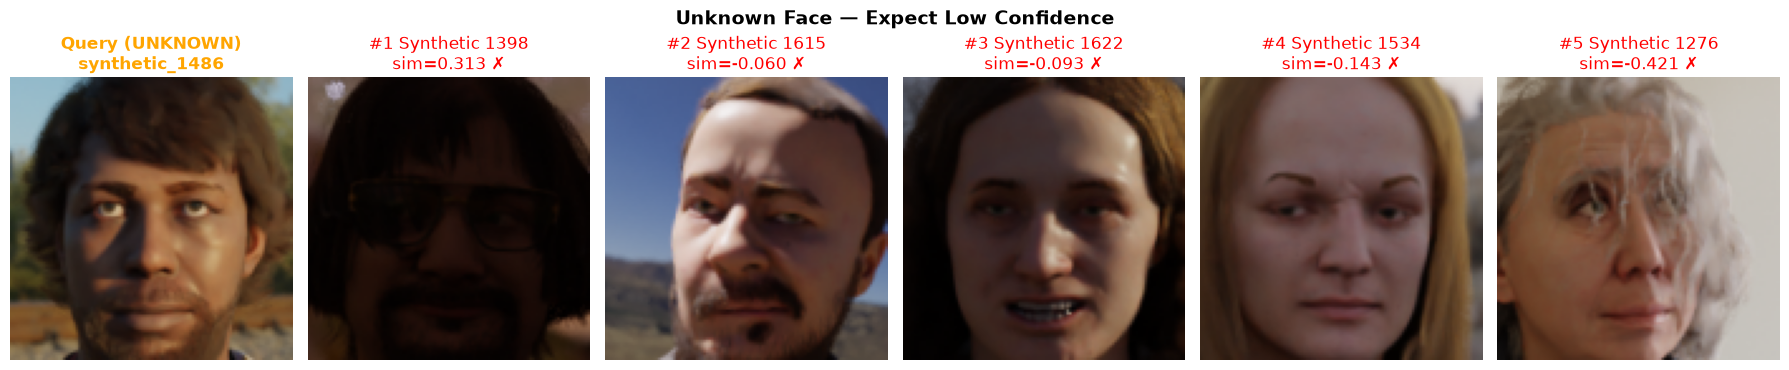

Confident matches: 0/5
✓ Correctly identified as unknown (no confident matches)


In [42]:
# Find a subject NOT in the gallery
enrolled_ids = {e['identity_id'] for e in gm.list_identities()}
unknown_subjects = [
    (sid, paths) for sid, paths in subject_images.items()
    if sid not in enrolled_ids and len(paths) >= 2
]

if unknown_subjects:
    unknown_sid, unknown_paths = random.choice(unknown_subjects)
    unknown_query = str(unknown_paths[0])

    results = gm.search(unknown_query, top_k=5)

    fig, axes = plt.subplots(1, len(results) + 1, figsize=(3 * (len(results) + 1), 4))
    axes[0].imshow(Image.open(unknown_query))
    axes[0].set_title(f'Query (UNKNOWN)\n{unknown_sid}', fontweight='bold', color='orange')
    axes[0].axis('off')

    for i, r in enumerate(results):
        ax = axes[i + 1]
        stored_images = gm.get_identity_image_paths(r['identity_id'])
        if stored_images:
            ax.imshow(Image.open(stored_images[0]))
        conf_marker = '✓' if r['confident'] else '✗'
        color = 'green' if r['confident'] else 'red'
        ax.set_title(
            f"#{i+1} {r['label']}\n"
            f"sim={r['similarity']:.3f} {conf_marker}",
            color=color,
        )
        ax.axis('off')

    plt.suptitle('Unknown Face — Expect Low Confidence', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    confident_count = sum(1 for r in results if r['confident'])
    print(f'Confident matches: {confident_count}/{len(results)}')
    if confident_count == 0:
        print('✓ Correctly identified as unknown (no confident matches)')
else:
    print('Could not find an unknown subject in the dataset')

## 7. Gallery Management

List, inspect, and clean up the gallery.

In [43]:
# List all identities
identities = gm.list_identities()
print(f'Gallery: {len(identities)} identities, {gm.total_image_count} total images\n')

for entry in identities:
    print(
        f"  {entry['identity_id']:<25} "
        f"{entry['label']:<20} "
        f"{entry['image_count']} image(s)"
    )

Gallery: 5 identities, 8 total images

  synthetic_1534            Synthetic 1534       4 image(s)
  synthetic_1615            Synthetic 1615       1 image(s)
  synthetic_1398            Synthetic 1398       1 image(s)
  synthetic_1622            Synthetic 1622       1 image(s)
  synthetic_1276            Synthetic 1276       1 image(s)


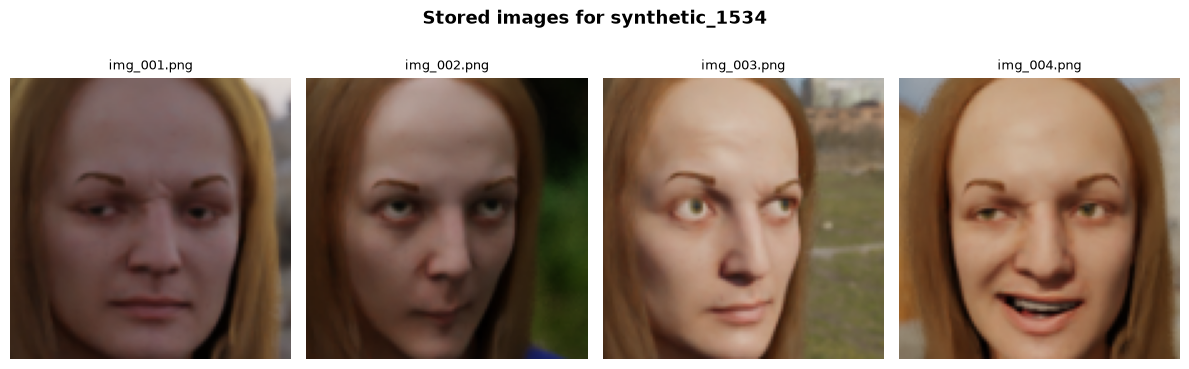

In [44]:
# Visualize all stored images for one identity
if identities:
    inspect_id = identities[0]['identity_id']
    stored = gm.get_identity_image_paths(inspect_id)

    cols = min(len(stored), 6)
    if cols > 0:
        fig, axes = plt.subplots(1, cols, figsize=(3 * cols, 4))
        if cols == 1:
            axes = [axes]
        for ax, img_path in zip(axes, stored[:cols]):
            ax.imshow(Image.open(img_path))
            ax.set_title(img_path.name, fontsize=9)
            ax.axis('off')
        plt.suptitle(
            f'Stored images for {inspect_id}',
            fontsize=13, fontweight='bold',
        )
        plt.tight_layout()
        plt.show()

## 8. Cleanup (Optional)

Delete all demo identities to reset the gallery.

In [45]:
# Uncomment to delete all demo identities:
# for identity in gm.list_identities():
#     gm.delete_identity(identity['identity_id'])
# print(f'Gallery cleared: {gm.identity_count} identities remain')